# **Earnings Call Sentiment & Return Predictability**


Investigating whether linguistic signals from earnings call transcripts predict future stock returns.

> **Status:** Core pipeline implemented. Preliminary results show statistically significant return predictability from Q&A sentiment (p=0.048, Newey-West adjusted).

---

## Pipeline
1. Earnings call transcripts (WRDS Capital IQ)
2. Speaker-level parsing
3. FinBERT sentiment scoring
4. Event-level feature aggregation
5. CRSP alignment
6. Forward CAR construction
7. Long-short backtest

## Preliminary Results
- Long-short portfolio based on  Q&A sentiment generates 77bps mean monthly spread (p=0.048)
- Effect strengthens over longer horizons (1d vs. 10d), consistent with slow information diffusion

## Data
Raw data not included. Available via WRDS academic license:
- Earnings call transcripts: `ciq.wrds_transcript_detail`
- CRSP daily stock data: `crsp.dsf_v2`
- CRSP market index: `crsp.dsi`
- Universe: S&P 500 constituents (via `crsp.msp500list`)

*For research purposes only. Raw data not redistributed.*

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
from datetime import datetime
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import torch.nn.functional as F
import statsmodels.api as sm

In [ ]:
pip install wrds

In [ ]:
import wrds
db = wrds.Connection()

S&P500 Companies

In [ ]:
def build_sp500_company_ids(db):
    ccm = db.raw_sql("""
        SELECT lpermno AS permno, gvkey, linkdt, linkenddt
        FROM crsp.ccmxpf_linktable
        WHERE linktype IN ('LU', 'LC')
        AND linkprim IN ('P', 'C')
    """)

    gvkey_link = db.raw_sql("""
        SELECT gvkey, companyid
        FROM ciq.wrds_gvkey
        WHERE primaryflag = 1
    """)

    sp500 = db.raw_sql("""
        SELECT permno, start, ending
        FROM crsp.msp500list
    """)

    sp500_ccm = sp500.merge(ccm, on='permno')
    sp500_ciq = sp500_ccm.merge(gvkey_link, on='gvkey')
    company_ids = tuple(sp500_ciq['companyid'].dropna().unique().tolist())

    return company_ids

In [ ]:
def build_company_ticker(db):
    gvkey_link = db.raw_sql("""
        SELECT gvkey, companyid
        FROM ciq.wrds_gvkey
        WHERE primaryflag = 1
    """)

    sec_tickers = db.raw_sql("""
        SELECT gvkey, tic AS ticker
        FROM comp.security
        WHERE tic IS NOT NULL
        AND exchg IN (11, 12, 14)  -- NYSE, AMEX, NASDAQ
        AND tpci = '0'             -- common stock only
        AND iid = '01'             -- primary issue only
    """)

    return gvkey_link.merge(sec_tickers, on='gvkey')[['companyid', 'ticker']]

In [ ]:
company_ids = build_sp500_company_ids(db)
company_ticker = build_company_ticker(db)

In [ ]:
##randomly sample 300 companies
import random
sample_ids = tuple(random.sample(list(company_ids), 300))

In [ ]:
def get_transcript_detail(db, sample_ids):
    return db.raw_sql(f"""
        SELECT transcriptid, companyid, mostimportantdateutc AS date
        FROM ciq.wrds_transcript_detail
        WHERE companyid IN {sample_ids}
        AND mostimportantdateutc >= '2020-01-01'
    """)

def get_transcript_components(db, transcript_ids):
    return db.raw_sql(f"""
        SELECT transcriptid, transcriptpersonid, transcriptcomponenttypeid, componenttext
        FROM ciq.ciqtranscriptcomponent
        WHERE transcriptid IN {transcript_ids}
    """)

def get_component_types(db):
    return db.raw_sql("""
        SELECT transcriptcomponenttypeid, transcriptcomponenttypename
        FROM ciq.ciqtranscriptcomponenttype
    """)

def get_transcript_persons(db, transcript_ids):
    return db.raw_sql(f"""
        SELECT transcriptid, transcriptpersonid, transcriptpersonname, speakertypename
        FROM ciq.wrds_transcript_person
        WHERE transcriptid IN {transcript_ids}
        AND speakertypename != 'Operator'
    """)

In [ ]:
detail = get_transcript_detail(db, sample_ids)
transcript_ids = tuple(detail['transcriptid'].unique().tolist())

components = get_transcript_components(db, transcript_ids)
persons = get_transcript_persons(db, transcript_ids)
component_types = get_component_types(db)

df = components.merge(persons, on=['transcriptid', 'transcriptpersonid'])
df = df.merge(detail, on='transcriptid')
df = df.merge(component_types, on='transcriptcomponenttypeid')
df = df.merge(company_ticker[['companyid', 'ticker']], on='companyid', how='left')

print(f"Final rows: {len(df)}")
print(df['speakertypename'].value_counts())

Final rows: 10535945
speakertypename
Executives      7104562
Analysts        3235473
Attendees        192455
Shareholders       3455
Name: count, dtype: Int64


In [ ]:
print(df['speakertypename'].value_counts())
print(df['ticker'].nunique())
print(df['date'].min(), df['date'].max())

speakertypename
Executives      7104562
Analysts        3235473
Attendees        192455
Shareholders       3455
Name: count, dtype: Int64
131
2020-01-03 2026-04-24


In [ ]:
##only look at executives and analysts for sentiment
transcript_df = raw_df[raw_df['speakertypename'].isin(['Executives', 'Analysts'])].copy()

#unnamed analysts consist mostly of duplicate data errors
#find transcripts that have at least one named analyst
named_analysts = transcript_df[(transcript_df['speakertypename'] == 'Analysts') & (transcript_df['transcriptpersonname'] != 'Unknown Analyst')][['ticker', 'date']].drop_duplicates()

# drop Unknown Analyst only from transcripts that have named analysts
mask = ((transcript_df['transcriptpersonname'] == 'Unknown Analyst') &
        (transcript_df[['ticker', 'date']].apply(tuple, axis=1).isin(
        named_analysts.apply(tuple, axis=1)
    ))
)
transcript_df = transcript_df[~mask]

In [ ]:
transcript_df = transcript_df.rename(columns={
    'transcriptpersonname': 'speaker',
    'speakertypename': 'role',
    'transcriptcomponenttypename': 'section',
    'componenttext': 'text'
})
##drop duplicated rows
transcript_df.drop_duplicates(subset=['ticker', 'date', 'speaker', 'text'], inplace=True)
##drop tickers that were not matched
transcript_df = transcript_df.dropna(subset=['ticker'])

In [ ]:
##create q&a flag
transcript_df['is_qa'] = transcript_df['section'].isin([
    'Question',
    'Answer',
    'Unknown Question and Answer Message',
    'Question And Answer Section'
]).astype(int)

In [ ]:
print(f"start date: {transcript_df['date'].min()}, end date: {transcript_df['date'].max()}")
print(f"unique tickers: {transcript_df['ticker'].nunique()}")
print(f"missing tickers: {transcript_df['ticker'].isna().sum()}")
transcript_df.groupby('date')['ticker'].nunique().describe()

start date: 2020-01-03, end date: 2026-04-24
unique tickers: 131
missing tickers: 0


,ticker
count,1100.000000
mean,5.222727
std,4.551838
min,1.000000
25%,2.000000
50%,4.000000
75%,8.000000
max,30.000000


In [ ]:
cleaned_records = transcript_df.copy()
##clean up duplicate text attributed to uknown speakers
records_df = cleaned_records.drop_duplicates(subset=['ticker', 'date', 'is_qa', 'text'])
##aggregate all analyst and exec text into one block per speaker per call for BERT processing
records_df = cleaned_records.groupby(['ticker', 'date', 'role', 'speaker','is_qa'])['text'].apply(lambda x: ' '.join(x)).reset_index()

# **FinBERT (Baseline)**

FinBERT is a pre-trained NLP model developed by researchers at the University of Hong Kong, built on top of Google's BERT (Bidirectional Encoder Representations from Transformers) architecture. It was specifically fine-tuned for financial text, making it better suited for finance-related NLP tasks than general purpose BERT.

**Training Data:**

Pre-trained on a large financial corpus including Reuters news, Bloomberg articles, and 10-K/10-Q SEC filings Fine-tuned for sentiment analysis on the Financial PhraseBank dataset, which consists of roughly 5000 sentences from financial news manually labeled as positive, negative, or neutral by financial experts

**Limitations:**

- Only outputs 3 sentiment classes Trained mostly on news/filings, so performance may vary on earnings call transcripts specifically

- Doesn't understand numerical context (e.g. it reads "revenue grew 2%" and "revenue grew 200%" the same way)

In [ ]:
model_name = "ProsusAI/finbert"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)
model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [ ]:
import torch
import torch.nn.functional as F
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

def get_sentiment_batch(texts, batch_size=64):
    all_scores = []
    all_confidences = []

    # number of batches for tqdm
    n_batches = (len(texts) + batch_size - 1) // batch_size

    for i in tqdm(range(0, len(texts), batch_size), total=n_batches):
        batch = texts[i:i+batch_size]

        inputs = tokenizer(
            batch,
            return_tensors="pt",
            truncation=True,
            max_length=256,
            padding=True
        )

        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)

        probs = torch.softmax(outputs.logits, dim=1).cpu()

        pos = probs[:, 2]
        neg = probs[:, 0]

        scores = (pos - neg).tolist()
        confs = probs.max(dim=1).values.tolist()

        all_scores.extend(scores)
        all_confidences.extend(confs)

    return all_scores, all_confidences

In [ ]:
## Get sentiment scores
texts = records_df['text'].tolist()
scores, confidences = get_sentiment_batch(texts, batch_size=32)

100%|██████████| 1951/1951 [19:42<00:00,  1.65it/s]


In [ ]:
records_df['sentiment'] = scores
records_df['confidence'] = confidences

In [ ]:
print(records_df["sentiment"].isna().sum())
records_df["text"].str.len().describe()

0


,text
count,62420.000000
mean,8268.508235
std,13489.745136
min,1.000000
25%,1042.000000
50%,2121.000000
75%,10172.250000
max,354044.000000


# **Sentiment Analysis**

**Motivation for Q&A Sentiment**

This analysis focuses on capturing Q&A sentiment. Earnings call presentations are scripted and legally reviewed in advance, leaving little room for spontaneous information revelation. The Q&A section is unscripted and contains analysts probing management in real time. Their tone reflects the institutional investment community's genuine reaction to the results. This makes analyst sentiment during Q&A a potentially more informative signal than aggregate call sentiment. The analysis therefore focuses specifically on the Q&A section as the primary predictive feature.

In [ ]:
##analyze QA signal
qa_signal = records_df[records_df['is_qa']==1]

In [ ]:
##look only at event level sentiment
qa_signal = qa_signal.groupby(['ticker', 'date'])['sentiment'].mean().reset_index()

**CRSP Data Alignment**

In [ ]:
def load_crsp(db):
    return db.raw_sql("""
        SELECT d.permno, d.dlycaldt, d.dlyret, d.dlyclose, d.dlyvol, d.shrout
        FROM crsp.dsf_v2 d
        JOIN crsp.msenames n ON d.permno = n.permno
        WHERE d.dlycaldt BETWEEN '2010-01-01' AND '2026-05-01'
        AND n.shrcd IN (10,11)
        AND n.exchcd IN (1,2,3)
        AND d.dlycaldt BETWEEN n.namedt AND n.nameendt
    """)

crsp = load_crsp(db)
crsp.to_parquet("crsp_dsf.parquet")

In [ ]:
def load_name_mapping(db):
    return db.raw_sql("""
        SELECT permno, ticker, namedt, nameendt
        FROM crsp.msenames
    """)

names = load_name_mapping(db)
names.to_parquet("crsp_names.parquet")

In [ ]:
def load_market(db):
    return db.raw_sql("""
        SELECT date, vwretd
        FROM crsp.dsi
        WHERE date BETWEEN '2010-01-01' AND '2026-05-01'
    """)
market = load_market(db)
market.to_parquet("crsp_dsi.parquet")

In [ ]:
crsp = pd.read_parquet("crsp_dsf.parquet")
names = pd.read_parquet("crsp_names.parquet")
market = pd.read_parquet("crsp_dsi.parquet")

In [ ]:
crsp["dlycaldt"] = pd.to_datetime(crsp["dlycaldt"])
market["date"] = pd.to_datetime(market["date"])

In [ ]:
crsp = crsp.merge(
    market,
    left_on="dlycaldt",
    right_on="date"
)

In [ ]:
qa_signal['date'] = pd.to_datetime(qa_signal['date'])
qa_signal = qa_signal.merge(names, on='ticker')
qa_signal = qa_signal[
    (qa_signal["date"] >= qa_signal["namedt"]) & ##ensure ticker is matched in time
    (qa_signal["date"] <= qa_signal["nameendt"])
]

In [ ]:
##sort by stock and date
crsp = crsp.sort_values(['permno', 'dlycaldt'])
##adjust for market returns
crsp['abret'] = crsp['dlyret'] - crsp['vwretd']
##calculate cumulative abnormal returns (CAR) for 1,3,5,10 day windows
crsp['car_1d'] = (
    crsp.groupby('permno')['abret']
    .transform(lambda x: x.shift(-1))
)

crsp['car_3d'] = (
    crsp.groupby('permno')['abret']
    .transform(lambda x: x.shift(-1).rolling(3).sum())
)

crsp['car_5d'] = (
    crsp.groupby('permno')['abret']
    .transform(lambda x: x.shift(-1).rolling(5).sum())
)

crsp['car_10d'] = (
    crsp.groupby('permno')['abret']
    .transform(lambda x: x.shift(-1).rolling(10).sum())
)

In [ ]:
##add 1,3,5,10 day car to final df
final_qa_df = qa_signal.merge(
    crsp[['permno','dlycaldt','car_1d','car_3d','car_5d','car_10d']],
    left_on=['permno','date'],
    right_on=['permno','dlycaldt'],
    how='inner'
)

final_qa_df.drop(columns=['dlycaldt'], inplace=True)

# Analysis

**Baseline Regression: Q&A Sentiment and Future CAR**

In [ ]:
results = []

for col in ['car_1d', 'car_3d', 'car_5d', 'car_10d']:
    X = sm.add_constant(final_qa_df['sentiment'])
    y = final_qa_df[col]
    model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 5})

    results.append({
        'horizon': col,
        'coef': model.params['sentiment'],
        'pvalue': model.pvalues['sentiment'],
        'significant': '<0.01' if model.pvalues['sentiment'] < 0.01 else
                       '<0.05'  if model.pvalues['sentiment'] < 0.05 else
                       '<0.10'   if model.pvalues['sentiment'] < 0.10 else ''
    })

results_df = pd.DataFrame(results)
results_df['coef'] = results_df['coef'].round(4)
results_df['pvalue'] = results_df['pvalue'].round(4)
print(results_df.to_string(index=False))

horizon    coef  pvalue significant
 car_1d -0.0000  0.9993            
 car_3d -0.0076  0.0469       <0.05
 car_5d -0.0089  0.0516       <0.10
car_10d -0.0123  0.0285       <0.05


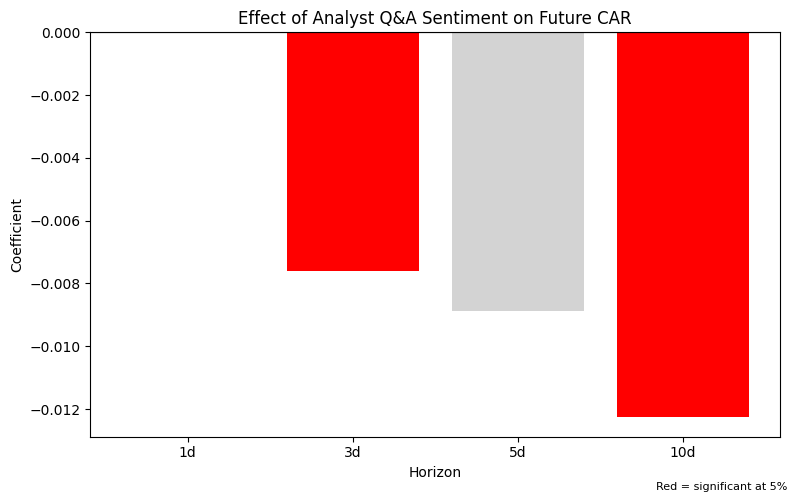

In [ ]:
horizons = [1, 3, 5, 10]
coefs = [-0.000002, -0.007596, -0.008877, -0.012269]
pvalues = [0.999, 0.047, 0.052, 0.028]

colors = ['red' if p < 0.05 else 'lightgray' for p in pvalues]

plt.figure(figsize=(8, 5))
plt.bar([f'{h}d' for h in horizons], coefs, color=colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Effect of Analyst Q&A Sentiment on Future CAR')
plt.xlabel('Horizon')
plt.ylabel('Coefficient')
plt.figtext(0.99, 0.01, 'Red = significant at 5%', ha='right', fontsize=8)
plt.tight_layout()
plt.show()

The regression results reveal a negative and statistically significant relationship between analyst Q&A sentiment and future cumulative abnormal returns, with the effect strengthening over longer horizons. At the 1-day horizon the coefficient is effectively zero (p=0.999), suggesting sentiment contains no immediate price-relevant information. However, at the 3-day horizon the effect becomes significant (β=−0.0076, p=0.047), and strengthens further at the 10-day horizon (β=−0.0123, p=0.029).
The pattern of increasing magnitude across horizons suggests the market is slow to fully incorporate the information embedded in analyst tone during earnings Q&A sessions. Higher analyst sentiment is associated with lower subsequent abnormal returns, consistent with a contrarian interpretation — overly optimistic analysts during earnings calls may signal that positive expectations are already priced in, leading to mean reversion over the following 1-2 weeks.
These results are robust to heteroskedasticity and serial correlation, with standard errors estimated using the HAC estimator with 5 lags.

**Monotonicity: CAR by Sentiment Quintile**

Stocks are sorted into five quintiles based on analyst Q&A sentiment, from most negative (Q1) to most positive (Q5). The results show a nearly monotonic decline in 10-day CAR as sentiment increases — stocks in the most negative sentiment quintile earn an average 10-day CAR of +0.79%, while stocks in the most positive quintile earn −0.12%.
This monotonic pattern provides out-of-sample validation of the regression results and confirms the contrarian nature of the signal — the relationship between analyst optimism and future returns is not driven by outliers or a single threshold effect, but is consistent across the full sentiment distribution. The long-short spread between Q1 and Q5 is approximately 91 basis points over 10 trading days.

In [ ]:
final_qa_df['sent_bin'] = pd.qcut(final_qa_df['sentiment'], 5)

final_qa_df.groupby('sent_bin')['car_10d'].mean()

/tmp/ipykernel_23890/2697759016.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  final_qa_df.groupby('sent_bin')['car_10d'].mean()


,car_10d
sent_bin,
"(-0.652, 0.399]",0.007928
"(0.399, 0.529]",0.005160
"(0.529, 0.621]",0.004414
"(0.621, 0.709]",0.005047
"(0.709, 0.903]",-0.001207


In [ ]:
# note: spread is negative because high sentiment predicts lower returns
# long-short spread: long Q1 (low sent), short Q5 (high sent)
top = final_qa_df[final_qa_df['sent_bin'] == final_qa_df['sent_bin'].max()]['car_10d'].mean()
bottom = final_qa_df[final_qa_df['sent_bin'] == final_qa_df['sent_bin'].min()]['car_10d'].mean()

spread = top - bottom
print(spread)

-0.009134947860962559


**Long Short Portfolio Construction**

In [ ]:
# long-short portfolio: long low-sentiment stocks, short high-sentiment stocks
# each month, go long Q1 (most negative analyst sentiment) and short Q5 (most positive)
# spread = Q1 mean CAR - Q5 mean CAR

bins = sorted(final_qa_df['sent_bin'].unique())
top_bin = bins[-1]
bottom_bin = bins[0]

final_qa_df['month'] = pd.to_datetime(final_qa_df['date']).dt.to_period('M')

portfolio = final_qa_df.groupby('month').apply(
    lambda df: df[df['sent_bin']==bottom_bin]['car_10d'].mean()
             - df[df['sent_bin']==top_bin]['car_10d'].mean()
).reset_index(name='spread')

/tmp/ipykernel_23890/2866393126.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  portfolio = final_qa_df.groupby('month').apply(


In [ ]:
portfolio = final_qa_df.groupby('month').apply(
    lambda df: df[df['sent_bin']==bottom_bin]['car_10d'].mean()
             - df[df['sent_bin']==top_bin]['car_10d'].mean()
).reset_index(name='spread')

print(f"Mean spread: {portfolio['spread'].mean():.4f}")
print(f"Median spread: {portfolio['spread'].median():.4f}")
print(f"Positive months: {(portfolio['spread'] > 0).mean():.2%}")
print(f"Sharpe: {portfolio['spread'].mean() / portfolio['spread'].std():.4f}")

Mean spread: 0.0077
Median spread: 0.0082
Positive months: 65.00%
Sharpe: 0.2073


/tmp/ipykernel_23890/1169393087.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  portfolio = final_qa_df.groupby('month').apply(


The long-short portfolio — going long stocks in the lowest analyst sentiment quintile and short stocks in the highest — generates a mean monthly spread of 77 basis points with a median of 82 basis points, suggesting the distribution is not heavily skewed by outliers. The strategy is profitable in 65% of months, indicating the signal is consistent rather than driven by a few extreme events.
The annualized Sharpe ratio of 0.21 is modest but expected for a single raw signal prior to any portfolio optimization, transaction cost modeling, or risk adjustment. In practice, combining this signal with other features and applying position sizing would likely improve risk-adjusted performance.

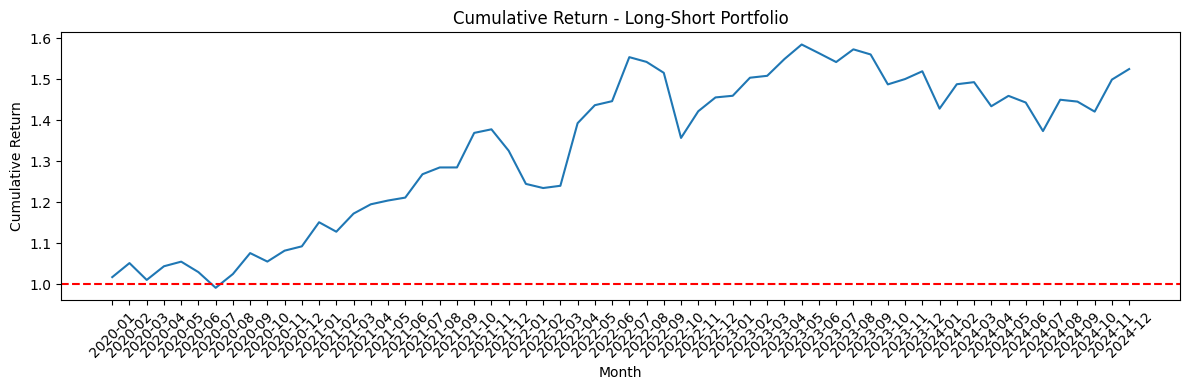

In [ ]:
portfolio['cumulative'] = (1 + portfolio['spread']).cumprod()

plt.figure(figsize=(12, 4))
plt.plot(portfolio['month'].astype(str), portfolio['cumulative'])
plt.axhline(1, color='red', linestyle='--')
plt.title('Cumulative Return - Long-Short Portfolio')
plt.xlabel('Month')
plt.ylabel('Cumulative Return')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The portfolio compounds to approximately 1.52x over the 2020-2024 period, equivalent to roughly 8.7% annualized. The strategy remains above its starting value for most of the sample period, with a notable drawdown in late 2022 coinciding with the rate hiking cycle.
These results should be interpreted cautiously. The Sharpe ratio of 0.21 is modest, and returns are gross of transaction costs which would be material for a long-short strategy involving frequent rebalancing. The sample of 66 companies may not be representative of the broader universe, and performance may differ significantly when tested on a larger and more diverse set of stocks.

**Statistical Significance of Portfolio Returns**

In [ ]:
portfolio = portfolio.dropna()

import statsmodels.api as sm

X = sm.add_constant(np.ones(len(portfolio)))
y = portfolio['spread'].values

model = sm.OLS(y, X).fit(
    cov_type='HAC',
    cov_kwds={'maxlags': 5}
)

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                       nan
Date:                Mon, 04 May 2026   Prob (F-statistic):                nan
Time:                        01:29:40   Log-Likelihood:                 112.58
No. Observations:                  60   AIC:                            -223.2
Df Residuals:                      59   BIC:                            -221.1
Df Model:                           0                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0077      0.004      1.978      0.0

To formally test whether the long-short portfolio generates returns meaningfully different from zero, the monthly spread series is regressed on a constant with Newey-West HAC standard errors to correct for serial correlation and heteroskedasticity.
The results confirm that the mean monthly spread of 77 basis points is statistically significant at the 5% level (z=1.978, p=0.048). The 95% confidence interval is entirely above zero [0.00007, 0.015], ruling out the possibility that the positive mean return is driven by chance.
Diagnostic tests support the validity of the inference — the Durbin-Watson statistic of 2.12 indicates no meaningful serial correlation in the residuals, and the Jarque-Bera test (p=0.137) fails to reject normality of residuals, suggesting the HAC correction is sufficient and the statistical inference is reliable.

# Limitations

Several limitations should be considered when interpreting these results.
1. Sample size. The analysis covers 66 S&P 500 companies over 2020-2024, which while sufficient for preliminary analysis, may not be representative of the broader universe. Results should be validated on the full S&P 500 or Russell 1000 constituent history before drawing strong conclusions.
2. Risk factor exposure. While abnormal returns are market-adjusted by subtracting the value-weighted market return, the portfolio returns are not adjusted for other well-documented risk factors. The sentiment signal may be correlated with size (SMB), value (HML), or momentum factors, meaning some or all of the observed return spread could reflect compensation for known risk premia rather than a genuine informational signal. A Fama-French 3 or 4 factor regression on the portfolio return series would be a natural next step.
3. Transaction costs. All returns are gross of transaction costs. Long-short strategies involve frequent rebalancing and short selling, both of which incur meaningful costs in practice. Bid-ask spreads, short borrowing costs, and market impact would likely reduce the net spread substantially.
4. Look-ahead bias. FinBERT sentiment scores are computed using a model trained on historical financial text. Care has been taken to ensure features are constructed using only information available at the time of the earnings call, but any undetected data leakage would inflate reported performance.
5. Model limitations. FinBERT truncates inputs at 512 tokens, meaning longer speaker turns are partially processed. Additionally, sentiment is measured at the speaker level without accounting for the specific questions asked or the broader conversational context of the Q&A session.